# Module 03 - Mô hình hóa và tầng quyết định

**Câu hỏi.** Trước khi giao, có thể dự báo đơn nào nguy cơ trễ để ưu
tiên theo dõi/điều phối không, và mô hình nào đáng tin nhất?

**Phương pháp.** Supervised learning theo đúng kỷ luật chống rò rỉ:

1. *Fit* preprocessing + model **chỉ trên train**.
2. *Chọn* mô hình trên **dev** theo F2 (ưu tiên không bỏ sót đơn trễ).
3. *Kiểm tra độ ổn định* bằng cross-validation trên train.
4. *Khóa* mô hình rồi **báo test một lần**, kèm khoảng tin cậy bootstrap.

**Quyết định đầu ra.** Một mô hình khóa + xác suất trễ để tầng DSS biến
thành Risk Score/Priority.

> Lưu ý đọc kết quả: dữ liệu là synthetic gần tất định (xem Module 06),
> nên điểm số rất cao phản ánh độ dễ của dữ liệu, **không** phải năng
> lực dự báo thực tế. Giá trị học thuật nằm ở *quy trình* và *cách đọc*.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
from IPython.display import Image
from pizza_dss.config import ACTIVE_FEATURE_COLUMNS, COMPACT_FEATURE_COLUMNS, FEATURE_COLUMNS, TARGET_COLUMN
from pizza_dss.data_loader import load_processed_splits, validate_feature_contract
from pizza_dss.decision_rules import get_dss_decision
from pizza_dss.modeling import (
    bootstrap_test_metrics,
    compare_feature_sets,
    compare_models,
    cross_validate_models,
    evaluate_baselines,
    load_best_model,
    metric_row,
    predict_delay_probability,
    train_and_evaluate,
)

**Khoá artifact chuẩn.** Cell dưới chạy `train_and_evaluate()` để sinh
model khóa + các hình đánh giá (so sánh model, confusion matrix, ROC,
hệ số, PR-curve) dùng chung cho notebook, slide và báo cáo.

In [2]:
_ = train_and_evaluate()

C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 0. Định nghĩa các metric (đọc trước khi xem bảng)

Lớp "trễ" là thiểu số (~21%), nên **không dùng Accuracy một mình**.

- **Accuracy**: tỷ lệ dự đoán đúng trên tổng. Dễ bị lớp đa số (on-time)
  đánh lừa.
- **Balanced Accuracy**: trung bình của Recall hai lớp; công bằng với
  lớp thiểu số.
- **Precision** = TP/(TP+FP): trong các đơn bị *cảnh báo trễ*, bao nhiêu
  % thực sự trễ. Cao = ít báo động giả.
- **Recall** (Sensitivity) = TP/(TP+FN): trong các đơn *thực sự trễ*,
  bắt được bao nhiêu %. Cao = ít bỏ sót.
- **F1** = trung bình điều hòa của Precision và Recall (cân bằng).
- **F2** = F-beta với beta=2, **ưu tiên Recall gấp đôi Precision**. Chọn
  vì bỏ sót đơn trễ (FN) tốn chi phí vận hành hơn cảnh báo dư (FP).
- **MCC** (Matthews): tương quan giữa dự đoán và thực tế trên cả 4 ô của
  confusion matrix; nằm trong [-1, 1], 0 = đoán mò. Bền với mất cân bằng.
- **ROC-AUC**: khả năng xếp hạng (đơn trễ có xác suất cao hơn đơn không
  trễ); 0.5 = ngẫu nhiên, 1.0 = hoàn hảo.
- **TN/FP/FN/TP**: bốn ô confusion matrix (đúng-âm/dương-giả/âm-giả/đúng-dương).

## 1. Split và feature contract

In [3]:
validate_feature_contract()
train_df, dev_df, test_df = load_processed_splits()
pd.DataFrame([
    {"split": "train", "rows": len(train_df), "delayed": int(train_df[TARGET_COLUMN].sum()),
     "delayed_rate": round(train_df[TARGET_COLUMN].mean(), 4)},
    {"split": "dev", "rows": len(dev_df), "delayed": int(dev_df[TARGET_COLUMN].sum()),
     "delayed_rate": round(dev_df[TARGET_COLUMN].mean(), 4)},
    {"split": "test", "rows": len(test_df), "delayed": int(test_df[TARGET_COLUMN].sum()),
     "delayed_rate": round(test_df[TARGET_COLUMN].mean(), 4)},
])

,split,rows,delayed,delayed_rate
0,train,602,126,0.2093
1,dev,201,42,0.2090
2,test,201,42,0.2090


**Insight.** `validate_feature_contract()` chạy không lỗi nghĩa là không
feature nào nằm trong danh sách rò rỉ. Tỷ lệ trễ ~21% được giữ đều ở cả
ba split (stratified). Test chỉ có ~42 đơn trễ — đây là lý do ở mục 5 ta
phải kèm khoảng tin cậy bootstrap thay vì tin tuyệt đối vào điểm số.

## 2. Baseline bắt buộc trên dev

In [4]:
evaluate_baselines(dev_df[TARGET_COLUMN]).round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
0,Always on-time,0.791,0.5,0.000,0.0,0.0000,0.0000,0.0,NaN,159,0,42,0
1,Always delayed,0.209,0.5,0.209,1.0,0.3457,0.5691,0.0,NaN,0,159,0,42


**Định nghĩa.** *Always on-time* = đoán mọi đơn không trễ; *Always
delayed* = đoán mọi đơn trễ. Đây là mốc tối thiểu mọi mô hình phải vượt.

**Insight.** Always-on-time đạt Accuracy ~0.79 nhưng **F2 = 0, MCC = 0**
(không bắt được đơn trễ nào) — minh chứng vì sao Accuracy gây hiểu lầm.
Always-delayed có Recall = 1 nhưng Precision thấp. Mô hình tốt phải vượt
cả hai về F2 và MCC.

## 3. So sánh feature set: full vs compact

In [5]:
{
    "full_pre_dispatch": FEATURE_COLUMNS,
    "compact_nonredundant": COMPACT_FEATURE_COLUMNS,
    "active_for_locked_model": ACTIVE_FEATURE_COLUMNS,
}

{'full_pre_dispatch': ['toppings_count',
  'distance_km',
  'topping_density',
  'estimated_duration_min',
  'pizza_complexity',
  'traffic_impact',
  'order_hour',
  'restaurant_name',
  'location',
  'pizza_size',
  'pizza_type',
  'traffic_level',
  'payment_method',
  'is_peak_hour',
  'is_weekend',
  'order_month',
  'payment_category'],
 'compact_nonredundant': ['toppings_count',
  'distance_km',
  'order_hour',
  'pizza_size_score',
  'restaurant_name',
  'location',
  'pizza_type',
  'traffic_level',
  'payment_category',
  'is_peak_hour',
  'is_weekend',
  'order_month'],
 'active_for_locked_model': ['toppings_count',
  'distance_km',
  'order_hour',
  'pizza_size_score',
  'restaurant_name',
  'location',
  'pizza_type',
  'traffic_level',
  'payment_category',
  'is_peak_hour',
  'is_weekend',
  'order_month']}

In [6]:
compare_feature_sets(train_df, dev_df).round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp,feature_count,note
1,compact_nonredundant,0.9701,0.9636,0.9091,0.9524,0.9302,0.9434,0.9117,0.9942,155,4,2,40,12,Drops formula-derived columns and uses pizza_s...
0,full_pre_dispatch,0.9701,0.9549,0.9286,0.9286,0.9286,0.9286,0.9097,0.9904,156,3,3,39,17,Includes engineered deterministic columns for ...


**Insight.** Compact bỏ các cột tất định (`estimated_duration_min`,
`topping_density`, `pizza_complexity`, `traffic_impact`) và mã hóa size
bằng `pizza_size_score` (1-4). Dev F2 của compact ngang hoặc nhỉnh hơn
full dù **ít feature hơn** → bằng chứng các cột công thức là *redundant*,
không thêm thông tin. Vì vậy mô hình khóa dùng compact (đơn giản, ít
nguy cơ overfit).

## 3b. Vì sao chọn đúng sáu classifier này?

Sáu mô hình phủ các họ thuật toán trong học phần, từ tuyến tính tới
ensemble, để so sánh công bằng.

In [7]:
pd.DataFrame([
    {"model": "Logistic Regression", "ho": "Tuyến tính/xác suất",
     "gia_dinh": "Log-odds tuyến tính theo feature", "vi_sao": "Baseline mạnh, hệ số diễn giải được"},
    {"model": "Decision Tree", "ho": "Cây",
     "gia_dinh": "Chia ngưỡng đệ quy, phi tuyến", "vi_sao": "Dễ giải thích luật if-then"},
    {"model": "Naive Bayes", "ho": "Xác suất sinh",
     "gia_dinh": "Feature độc lập có điều kiện, Gaussian", "vi_sao": "Nhanh, mốc tham chiếu"},
    {"model": "k-NN", "ho": "Dựa lân cận",
     "gia_dinh": "Đơn giống nhau thì cùng nhãn", "vi_sao": "Phi tham số, nhạy với scaling"},
    {"model": "SVM (RBF)", "ho": "Biên cực đại",
     "gia_dinh": "Tách lớp bằng kernel phi tuyến", "vi_sao": "Mạnh khi biên phức tạp"},
    {"model": "Random Forest", "ho": "Ensemble bagging",
     "gia_dinh": "Trung bình nhiều cây ngẫu nhiên", "vi_sao": "Giảm phương sai, robust"},
])

,model,ho,gia_dinh,vi_sao
0,Logistic Regression,Tuyến tính/xác suất,Log-odds tuyến tính theo feature,"Baseline mạnh, hệ số diễn giải được"
1,Decision Tree,Cây,"Chia ngưỡng đệ quy, phi tuyến",Dễ giải thích luật if-then
2,Naive Bayes,Xác suất sinh,"Feature độc lập có điều kiện, Gaussian","Nhanh, mốc tham chiếu"
3,k-NN,Dựa lân cận,Đơn giống nhau thì cùng nhãn,"Phi tham số, nhạy với scaling"
4,SVM (RBF),Biên cực đại,Tách lớp bằng kernel phi tuyến,Mạnh khi biên phức tạp
5,Random Forest,Ensemble bagging,Trung bình nhiều cây ngẫu nhiên,"Giảm phương sai, robust"


**Insight.** Mỗi họ có điểm mạnh khác nhau; so sánh trên cùng feature
set và cùng metric giúp lựa chọn dựa trên bằng chứng, không cảm tính.

## 4. So sánh sáu classifier trên dev (một lần split)

In [8]:
dev_metrics, fitted = compare_models(train_df, dev_df)
dev_metrics.round(4)

C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
0,Logistic Regression,0.9701,0.9636,0.9091,0.9524,0.9302,0.9434,0.9117,0.9942,155,4,2,40
4,SVM,0.9602,0.9398,0.9048,0.9048,0.9048,0.9048,0.8796,0.9931,155,4,4,38
1,Decision Tree,0.9552,0.8929,1.0000,0.7857,0.8800,0.8209,0.8623,0.8929,159,0,9,33
3,k-NN,0.9353,0.8540,0.9677,0.7143,0.8219,0.7538,0.7970,0.9668,158,1,12,30
5,Random Forest,0.8408,0.8205,0.5893,0.7857,0.6735,0.7366,0.5814,0.9084,136,23,9,33
2,Naive Bayes,0.6368,0.7179,0.3495,0.8571,0.4966,0.6642,0.3544,0.7844,92,67,6,36


**Cách đọc.** Bảng đã sắp theo F2 giảm dần (rồi Balanced Accuracy, MCC).
Cột tn/fp/fn/tp cho thấy cơ cấu lỗi của từng mô hình.

**Insight.** Logistic Regression đứng đầu F2/MCC; Naive Bayes có Recall
cao nhưng nhiều FP nên Precision và F2 thấp. Đây mới là **một lần** chia
dev nên cần kiểm tra độ ổn định ở mục 4b.

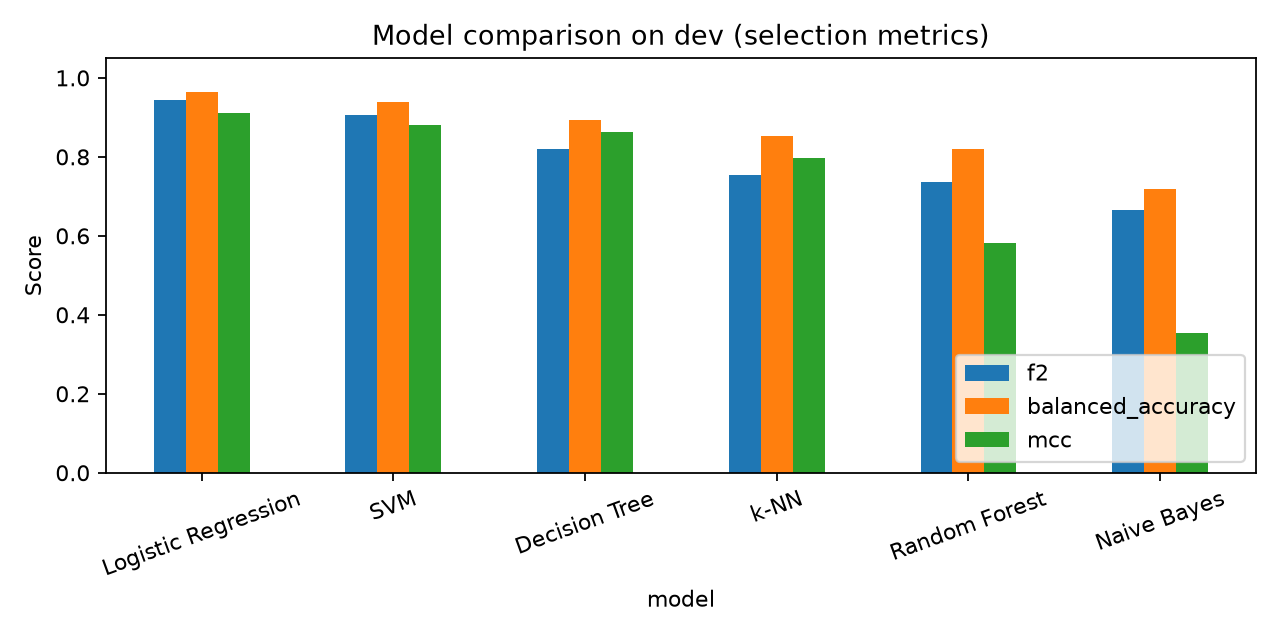

In [9]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "model_comparison.png"))

**Insight (hình).** Trực quan hóa khoảng cách F2/Balanced-Accuracy/MCC giữa các mô hình: nhóm tuyến tính/SVM/cây vượt trội, Naive Bayes tụt lại.

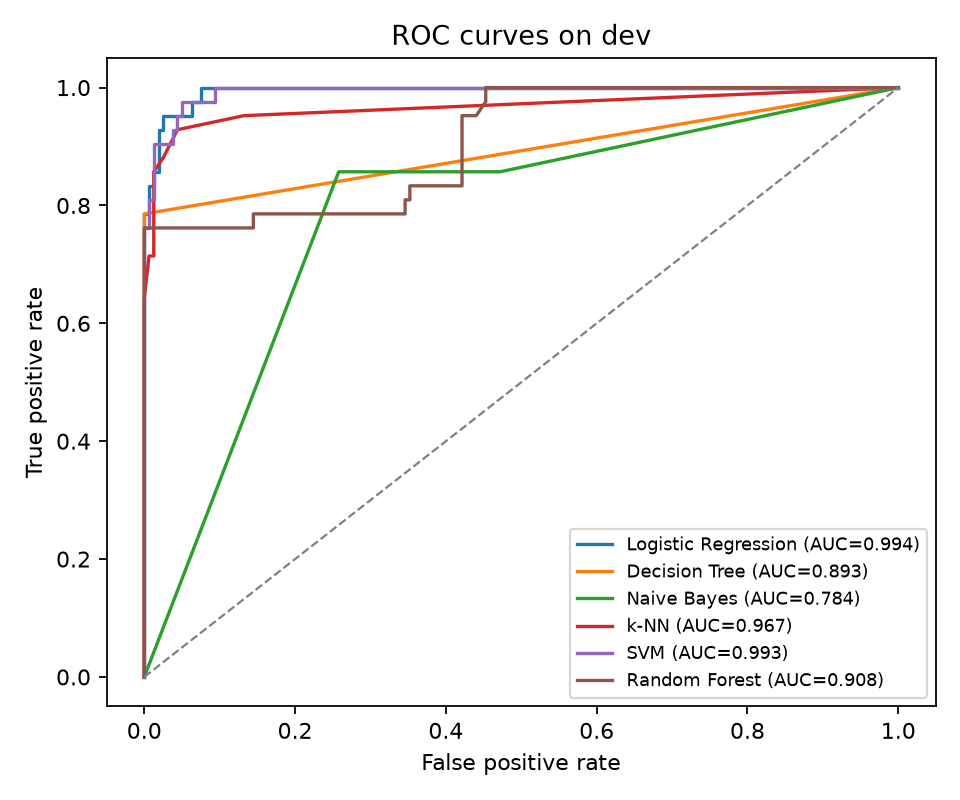

In [10]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "roc_curves.png"))

**Insight (hình).** ROC nằm sát góc trên-trái = tách lớp tốt; AUC trong chú thích xác nhận Logistic Regression và SVM xếp hạng rủi ro tốt nhất.

## 4b. Cross-validation trên train (kiểm tra độ ổn định)

**Định nghĩa.** Stratified k-fold: chia train thành k phần giữ nguyên tỷ
lệ trễ, lần lượt train trên k-1 phần và đánh giá trên phần còn lại. Báo
mean ± std để thấy mô hình *ổn định* hay *may rủi theo split*.

In [11]:
cross_validate_models(train_df, k=5).round(4)

C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\doand\Desktop\Workspace\1-Projects\ml-dss\pizza_delivery_dss\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,cv_folds,f2_mean,f2_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,roc_auc_mean,roc_auc_std
0,SVM,5,0.9447,0.0426,0.9649,0.0263,0.9177,0.0338,0.9971,0.0029
1,Logistic Regression,5,0.9387,0.0323,0.9609,0.0204,0.9123,0.0390,0.9952,0.0041
2,Decision Tree,5,0.8307,0.0318,0.8979,0.0179,0.8575,0.0298,0.8979,0.0179
3,k-NN,5,0.8301,0.0918,0.8988,0.0526,0.8612,0.0672,0.9931,0.0022
4,Random Forest,5,0.7565,0.0536,0.8278,0.0447,0.5868,0.0991,0.9262,0.0160
5,Naive Bayes,5,0.7192,0.0495,0.7717,0.0369,0.4443,0.0622,0.7783,0.0512


**Insight.** F2 trung bình 5-fold cao và **độ lệch chuẩn nhỏ** ở các mô
hình dẫn đầu → kết quả không phải nhờ một split may mắn. Logistic
Regression vừa cao vừa ổn định, củng cố lựa chọn làm mô hình khóa.

## 5. Test sau khi khóa mô hình (báo một lần)

In [12]:
best_name = dev_metrics.iloc[0]["model"]
best_model = fitted[best_name]
prob = predict_delay_probability(best_model, test_df)
pred = prob >= 0.5
pd.DataFrame([metric_row(best_name, test_df[TARGET_COLUMN], pred, prob)]).round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
0,Logistic Regression,0.9602,0.9661,0.8542,0.9762,0.9111,0.9491,0.8889,0.9961,152,7,1,41


**Insight.** Mô hình khóa vượt xa cả hai baseline trên test. Recall cao = ít bỏ sót đơn trễ, đúng mục tiêu vận hành.

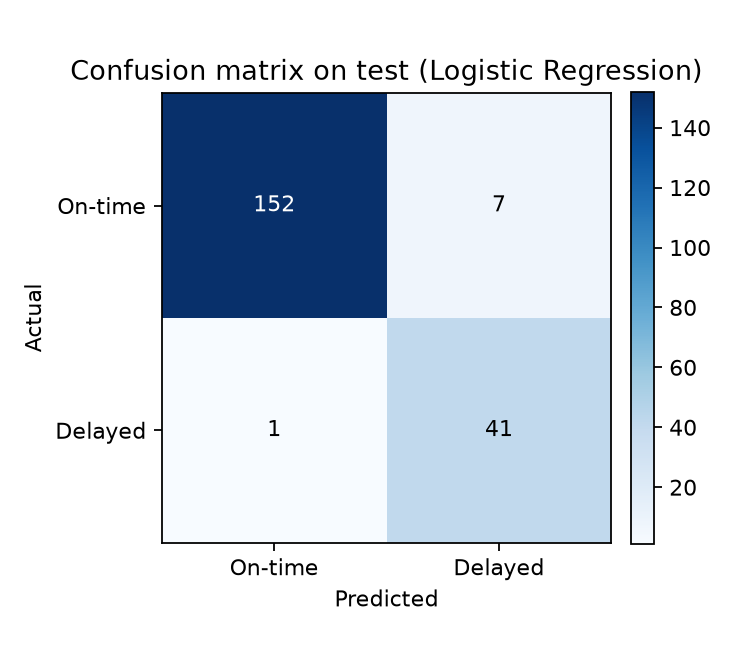

In [13]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "confusion_matrix_test.png"))

**Insight (hình).** Đọc theo chi phí vận hành: ô **FN** (đơn trễ bị bỏ
sót) là tốn nhất vì khách không được cảnh báo; ô **FP** chỉ tốn công theo
dõi dư. Mô hình giữ FN rất thấp — phù hợp việc tối ưu F2.

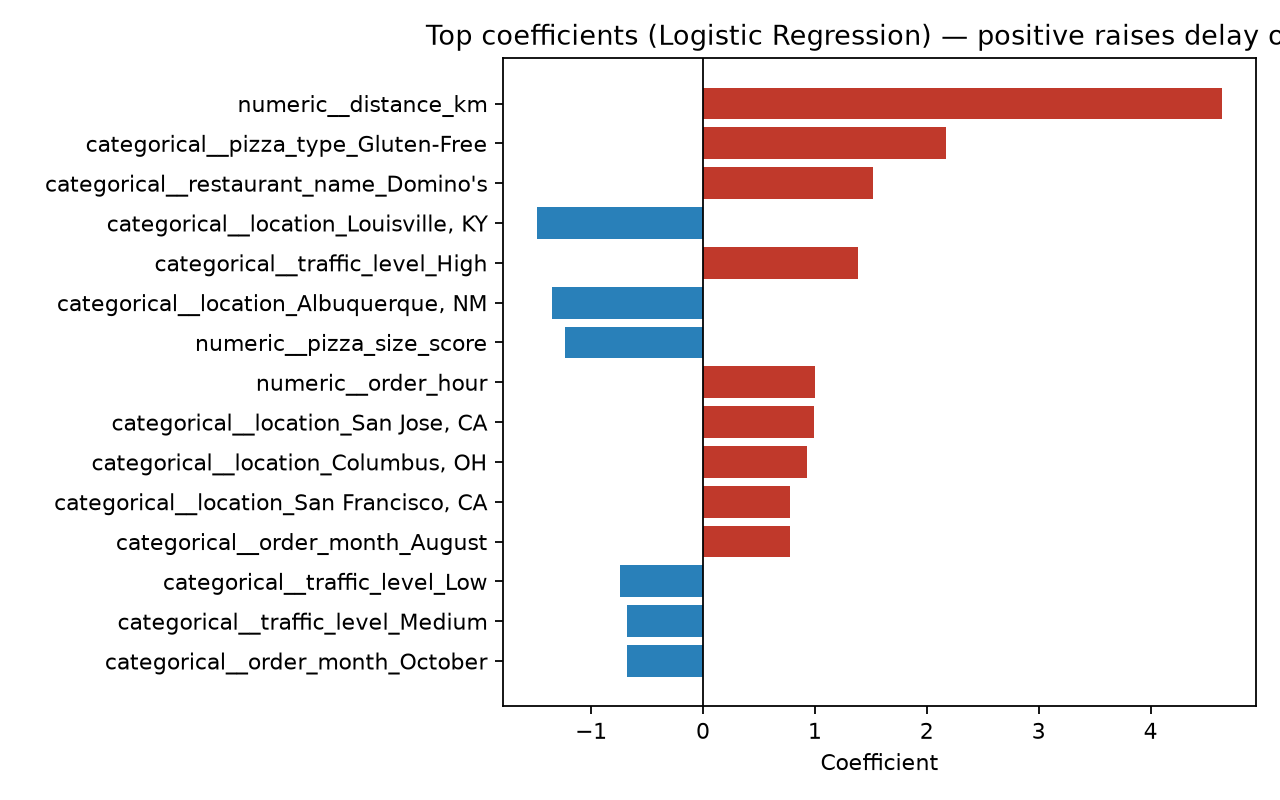

In [14]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "model_coefficients.png"))

**Insight (hình).** Hệ số dương lớn ở distance/traffic cao = các yếu tố này tăng odds trễ, khớp EDA và công thức Risk Score (Module 04).

## 5b. Khoảng tin cậy bootstrap cho metric test

**Định nghĩa.** Lấy mẫu lại có hoàn lại từ 201 đơn test nhiều lần, tính
metric mỗi lần, lấy phân vị 2.5%-97.5% làm khoảng tin cậy 95%. Cần thiết
vì test chỉ ~42 đơn trễ, một vài FN có thể làm điểm dao động mạnh.

In [15]:
bootstrap_test_metrics(best_model, test_df, n_boot=2000)

,metric,point_estimate,ci_low_2_5,ci_high_97_5,bootstrap_std,n_boot
0,f2,0.9491,0.8955,0.9859,0.0229,2000
1,balanced_accuracy,0.9661,0.9329,0.9904,0.0145,2000
2,mcc,0.8889,0.8083,0.9583,0.0381,2000
3,recall,0.9762,0.9189,1.0000,0.0235,2000


**Insight.** Khoảng tin cậy của F2/MCC khá **rộng** (do n nhỏ), nên phải
trình bày điểm test kèm CI, **không** tuyên bố một con số tuyệt đối. Đây
là cách đọc trung thực với cỡ mẫu nhỏ.

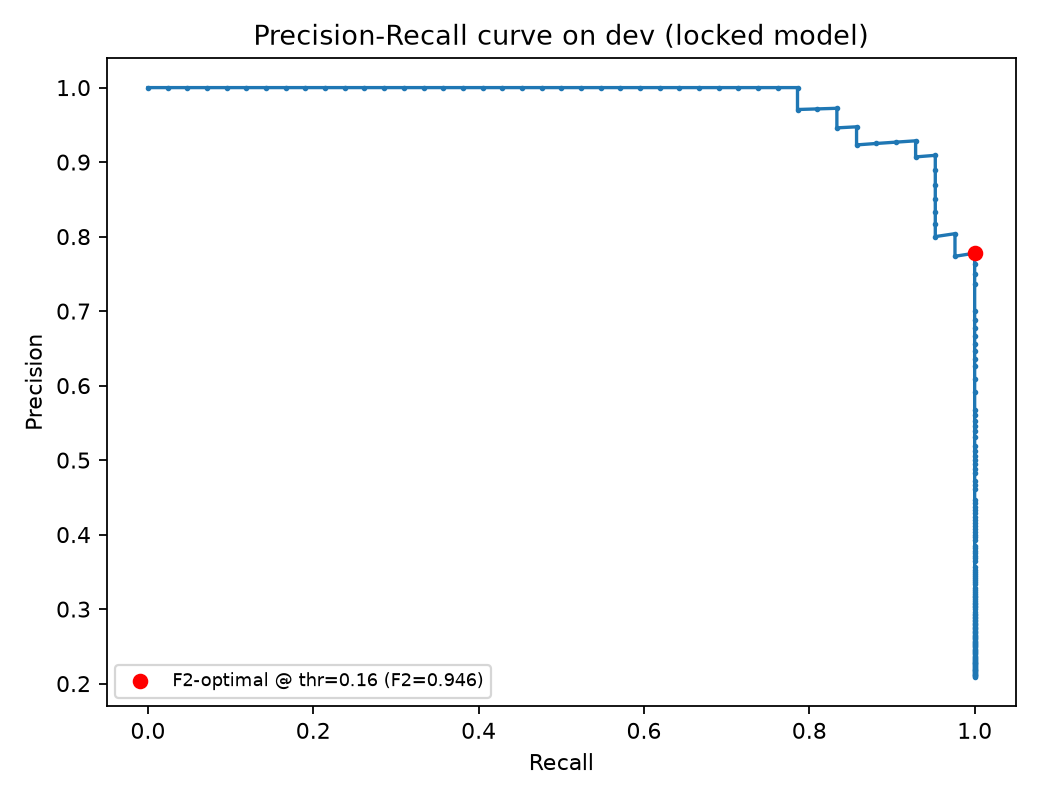

In [16]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "pr_curve.png"))

**Insight (hình).** Đường Precision-Recall và điểm F2-optimal cho thấy vì
sao ngưỡng vận hành có thể lệch khỏi 0.5: muốn tối đa F2 (ưu tiên Recall),
ngưỡng tối ưu thường thấp hơn, đánh đổi thêm vài FP để bắt thêm đơn trễ.

## 6. Baseline test (đối chứng)

In [17]:
evaluate_baselines(test_df[TARGET_COLUMN]).round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
0,Always on-time,0.791,0.5,0.000,0.0,0.0000,0.0000,0.0,NaN,159,0,42,0
1,Always delayed,0.209,0.5,0.209,1.0,0.3457,0.5691,0.0,NaN,0,159,0,42


**Insight.** Đặt cạnh mục 5 để thấy mức cải thiện thực của mô hình so với đoán-một-lớp; luôn báo baseline cạnh kết quả cuối.

## 7. Ví dụ tầng DSS trên hàng đợi test

In [18]:
model = load_best_model()
probabilities = predict_delay_probability(model, test_df)
rows = []
for i, (_, order) in enumerate(test_df.head(10).iterrows()):
    decision = get_dss_decision(order, probabilities[i])
    rows.append({
        "order_id": order["order_id"],
        "traffic_level": order["traffic_level"],
        "distance_km": order["distance_km"],
        "true_is_delayed": order["is_delayed"],
        **decision,
    })
pd.DataFrame(rows).sort_values("delay_risk_score", ascending=False)

,order_id,traffic_level,distance_km,true_is_delayed,delayed_probability,delay_risk_score,priority,recommended_action
0,ORD002,High,5.0,False,0.1790,44.0,Medium,Monitor driver assignment and traffic conditio...
2,ORD009,High,5.0,False,0.0376,38.7,Medium,Monitor driver assignment and traffic conditio...
1,ORD006,High,3.0,False,0.0231,32.5,Low,Keep in normal queue but watch traffic because...
7,ORD028,High,3.5,False,0.0101,32.4,Low,Keep in normal queue but watch traffic because...
9,ORD036,Medium,4.5,False,0.0116,28.2,Low,Keep in normal delivery queue.
8,ORD033,Medium,3.5,False,0.0037,26.0,Low,Keep in normal delivery queue.
3,ORD014,Low,4.0,False,0.0018,24.7,Low,Keep in normal delivery queue.
5,ORD018,Medium,3.5,False,0.0017,24.7,Low,Keep in normal delivery queue.
6,ORD027,Medium,2.0,False,0.0005,22.8,Low,Keep in normal delivery queue.
4,ORD017,Low,2.0,False,0.0002,15.6,Low,Keep in normal delivery queue.


**Insight.** Xác suất trễ được biến thành `delay_risk_score`, `priority`
và `recommended_action`. Risk Score là **chính sách minh bạch**, không
phải nhãn học từ dữ liệu — chi tiết công thức ở Module 04.

## 8. Insight → quyết định mô hình hóa

In [19]:
pd.DataFrame([
    {"cau_hoi": "Metric chọn mô hình?", "bang_chung": "Trễ là thiểu số ~21%; FN đắt hơn FP.",
     "quyet_dinh": "Chọn theo F2 trên dev, báo kèm Balanced Acc/MCC, không dùng Accuracy đơn lẻ."},
    {"cau_hoi": "Feature set nào?", "bang_chung": "Compact F2 >= full dù ít cột; cột công thức redundant.",
     "quyet_dinh": "Khóa mô hình trên compact (12 feature)."},
    {"cau_hoi": "Mô hình nào?", "bang_chung": "LogReg dẫn đầu F2/MCC, CV ổn định, hệ số diễn giải được.",
     "quyet_dinh": "Khóa Logistic Regression."},
    {"cau_hoi": "Điểm test tin được không?", "bang_chung": "n=201 (~42 trễ); CI bootstrap rộng.",
     "quyet_dinh": "Báo test kèm CI; không overclaim; nêu rõ dữ liệu synthetic."},
])

,cau_hoi,bang_chung,quyet_dinh
0,Metric chọn mô hình?,Trễ là thiểu số ~21%; FN đắt hơn FP.,"Chọn theo F2 trên dev, báo kèm Balanced Acc/MC..."
1,Feature set nào?,Compact F2 >= full dù ít cột; cột công thức re...,Khóa mô hình trên compact (12 feature).
2,Mô hình nào?,"LogReg dẫn đầu F2/MCC, CV ổn định, hệ số diễn ...",Khóa Logistic Regression.
3,Điểm test tin được không?,n=201 (~42 trễ); CI bootstrap rộng.,Báo test kèm CI; không overclaim; nêu rõ dữ li...
